In [3]:
import pandas as pd

# 1. 读取文件
file_path = 'combined_FDD (1).xls'
df = pd.read_excel(file_path)

# 2. 展示前 10 行
print("数据读取成功！")
df.head(10)

数据读取成功！


,Time,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling
0,2024-01-01 00,18,22.57,35.70,1.0,10.0,42.50,42.27,2.0,1.0,0.0,1.0,Sensor fault
1,2024-01-01 01,18,22.36,35.63,1.0,10.0,42.41,42.33,2.0,1.0,0.0,1.0,Sensor fault
2,2024-01-01 02,18,22.22,35.52,1.0,10.0,42.87,42.24,2.0,1.0,0.0,1.0,Sensor fault
3,2024-01-01 03,18,22.12,35.55,1.0,10.0,42.99,42.21,2.0,1.0,0.0,1.0,Sensor fault
4,2024-01-01 04,18,22.04,35.47,1.0,10.0,42.70,42.25,2.0,1.0,0.0,1.0,Sensor fault
5,2024-01-01 05,18,22.09,35.54,1.0,10.0,42.43,42.32,2.0,1.0,0.0,1.0,Sensor fault
6,2024-01-01 06,18,22.08,35.59,1.0,10.0,42.40,42.27,2.0,1.0,0.0,1.0,Sensor fault
7,2024-01-01 07,18,22.13,35.53,1.0,10.0,43.04,42.27,2.0,1.0,0.0,1.0,Sensor fault
8,2024-01-01 08,18,22.11,35.59,1.0,10.0,42.99,42.28,2.0,1.0,0.0,1.0,Sensor fault
9,2024-01-01 09,18,22.13,35.63,1.0,10.0,42.73,42.24,2.0,1.0,0.0,1.0,Sensor fault


🎯 成功锁定文件！路径为: ..\01_raw_rata\combined_FDD (1).xls

📊 第一步：数据质量全扫描结果：


,缺失值数量,缺失率 (%),平均值,最小值,最大值
Time,0,0.0,NaN,NaN,NaN
Set Temperature,0,0.0,18.86,18.00,30.00
Ventilation Temperature,0,0.0,13.34,-1.63,28.13
Supply Air Temperature,0,0.0,24.51,8.58,47.92
Supply Fan,0,0.0,0.20,0.00,1.00
Valve Position,0,0.0,14.42,8.46,100.00
Heating Supply Temperature 1,0,0.0,37.67,19.57,58.84
Heating Supply Temperature 2,0,0.0,36.35,18.95,54.38
Total Heating Pump,0,0.0,1.24,0.25,2.00
Heating Pump 1,0,0.0,0.11,0.00,1.00



📉 缺失值分布矩阵图加载中...


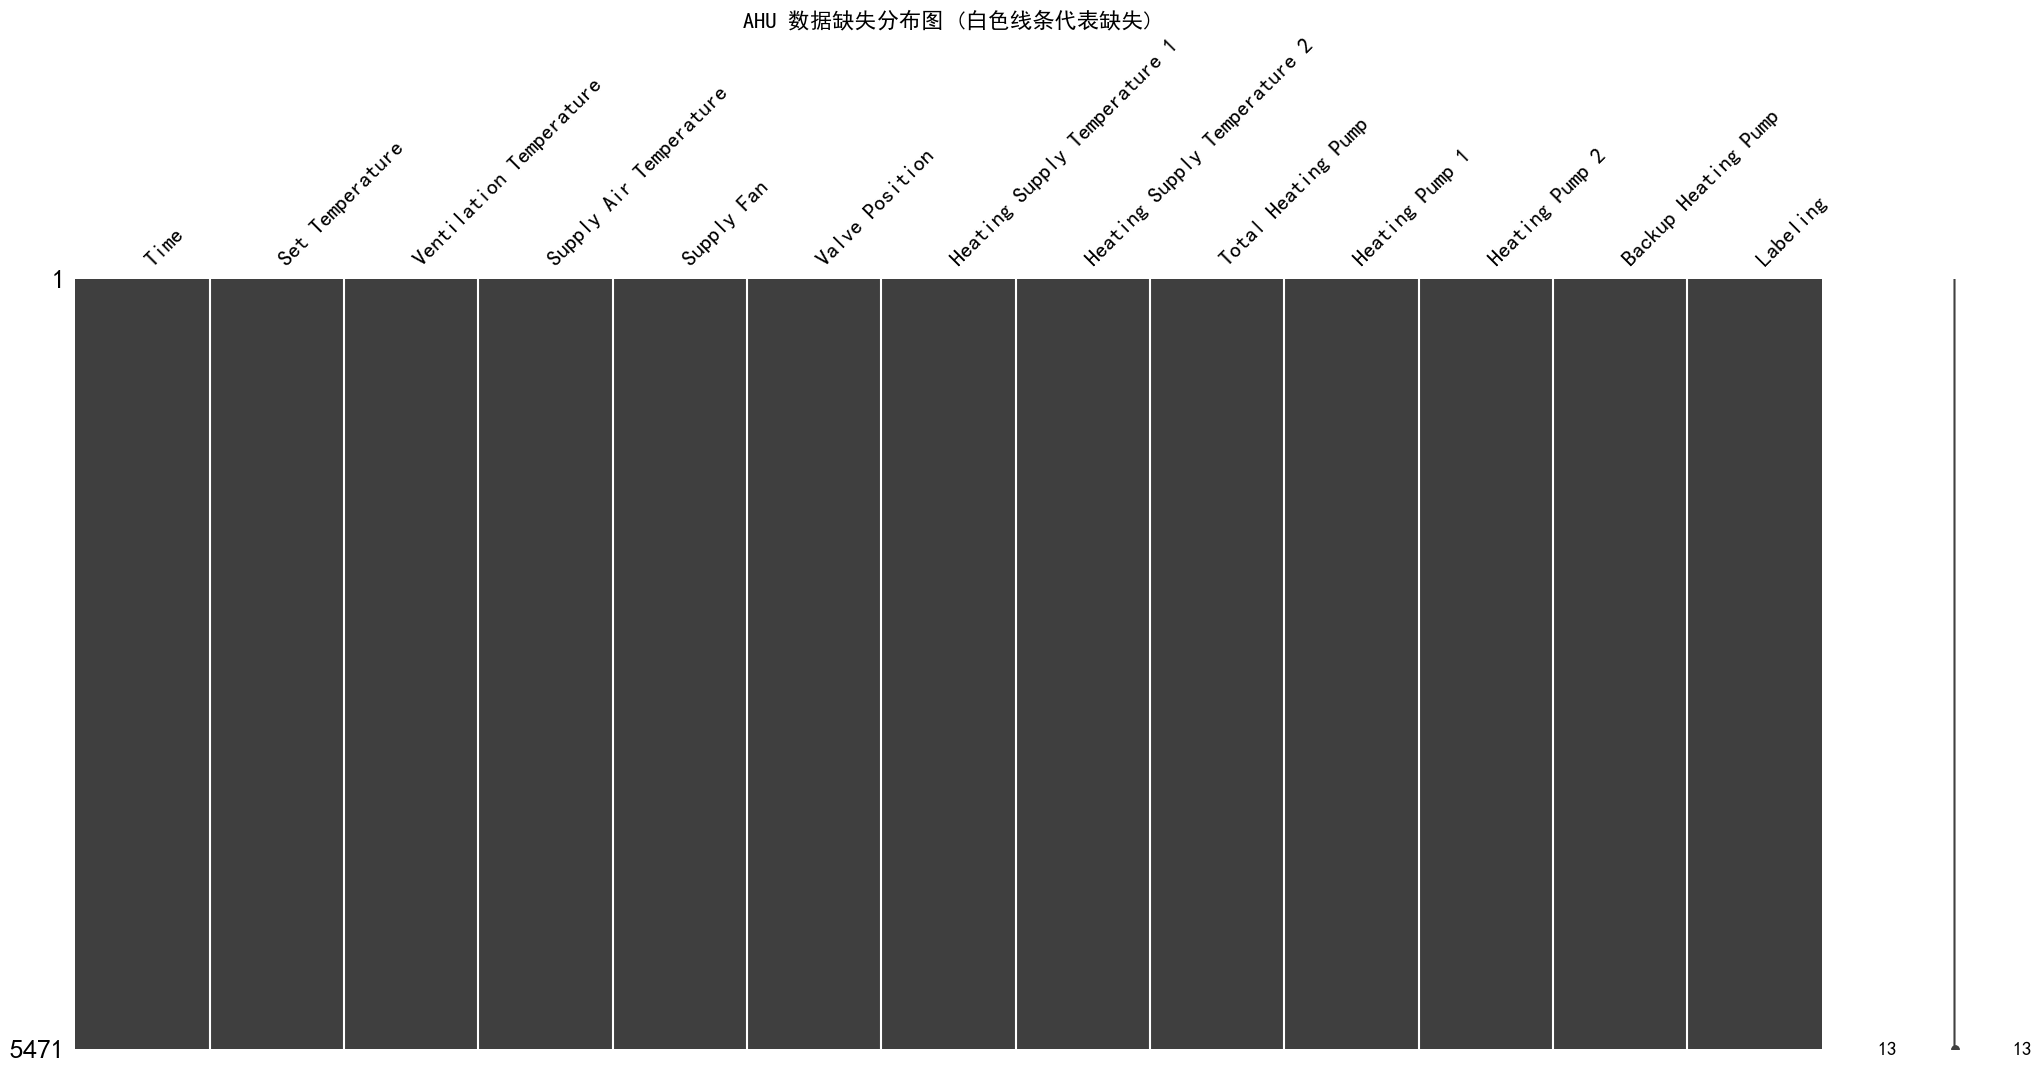

In [9]:
import pandas as pd
import os
import glob
import missingno as msno
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. 智能文件定位 (寻找 combined_FDD (1).xls)
# ---------------------------------------------------------
# 向上搜索两层的所有 xls 文件，精准捕捉路径
search_pattern = os.path.join("..", "**", "combined_FDD (1).xls")
files = glob.glob(search_pattern, recursive=True)

if not files:
    # 如果没找到，再扩大范围搜索一次
    files = glob.glob("**/*.xls", recursive=True)

if files:
    file_path = files[0]
    print(f"🎯 成功锁定文件！路径为: {file_path}")
    df = pd.read_excel(file_path)
    
    # ---------------------------------------------------------
    # 1. 统计质量报告 (缺失率、极值、均值)
    # ---------------------------------------------------------
    stats = pd.DataFrame()
    stats['缺失值数量'] = df.isnull().sum()
    stats['缺失率 (%)'] = (df.isnull().mean() * 100).round(2)
    stats['平均值'] = df.mean(numeric_only=True).round(2)
    stats['最小值'] = df.min(numeric_only=True)
    stats['最大值'] = df.max(numeric_only=True)

    print("\n📊 第一步：数据质量全扫描结果：")
    display(stats)

    # ---------------------------------------------------------
    # 2. 缺失值可视化 (使用 missingno)
    # ---------------------------------------------------------
    # 设置支持中文的字体（如果你的系统没有这些字体，图表标题可能显示乱码，但矩阵图本身是正常的）
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False

    print("\n📉 缺失值分布矩阵图加载中...")
    msno.matrix(df)
    plt.title("AHU 数据缺失分布图 (白色线条代表缺失)", fontsize=16)
    plt.show()
    
else:
    print("❌ 警告：扫描了整个文件夹还是没找到 'combined_FDD (1).xls'。")
    print("请确认文件名里是否有空格，或者括号 (1) 是半角还是全角符号。")

In [13]:
import numpy as np

# ---------------------------------------------------------
# 第二步：基于物理常识的数值过滤 (Data Masking)
# ---------------------------------------------------------

# 1. 定义需要校验的温度列
temp_columns = [
    'Set Temperature', 
    'Ventilation Temperature', 
    'Supply Air Temperature', 
    'Heating Supply Temperature 1', 
    'Heating Supply Temperature 2'
]

# 2. 执行过滤：超出 0~50℃ 的设为 NaN
for col in temp_columns:
    # 统计过滤前的异常数
    invalid_count = df[(df[col] < 0) | (df[col] > 50)].shape[0]
    
    if invalid_count > 0:
        print(f"⚠️ 列 [{col}] 发现 {invalid_count} 个超出物理范围 (0-50℃) 的异常值，已设为空值。")
        # 将异常值替换为 NaN
        df.loc[(df[col] < 0) | (df[col] > 50), col] = np.nan
    else:
        print(f"✅ 列 [{col}] 数据均在 0-50℃ 合理范围内。")

# 3. 校验阀门开度：必须在 0~100% 之间
valve_col = 'Valve Position'
invalid_valve = df[(df[valve_col] < 0) | (df[valve_col] > 100)].shape[0]
if invalid_valve > 0:
    df.loc[(df[valve_col] < 0) | (df[valve_col] > 100), valve_col] = np.nan
    print(f"⚠️ 列 [{valve_col}] 发现 {invalid_valve} 个非法开度值，已修正。")

print("\n✨ 第二步：物理过滤完成！")

✅ 列 [Set Temperature] 数据均在 0-50℃ 合理范围内。
✅ 列 [Ventilation Temperature] 数据均在 0-50℃ 合理范围内。
✅ 列 [Supply Air Temperature] 数据均在 0-50℃ 合理范围内。
⚠️ 列 [Heating Supply Temperature 1] 发现 62 个超出物理范围 (0-50℃) 的异常值，已设为空值。
⚠️ 列 [Heating Supply Temperature 2] 发现 7 个超出物理范围 (0-50℃) 的异常值，已设为空值。

✨ 第二步：物理过滤完成！


In [14]:
import pandas as pd

# ---------------------------------------------------------
# 第三步：时间尺度对齐与重采样 (Resampling)
# ---------------------------------------------------------

# 1. 确保 Time 列为真日期格式并设为索引 (重采样必须要求索引为 datetime)
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'])
    df = df.set_index('Time')

# 2. 对数值型列执行 15 分钟重采样，计算窗口内的均值 (mean)
# 这样做可以平滑掉小波动，并填补第二步产生的少量 NaN 空洞
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric_resampled = df[numeric_cols].resample('15T').mean()

# 3. 对非数值列 (如故障标签 Labeling) 执行重采样
# 故障标签不能求平均，我们取窗口内的第一个值 (first) 或众数
if 'Labeling' in df.columns:
    df_label_resampled = df[['Labeling']].resample('15T').first()
    # 合并数据
    df = pd.concat([df_numeric_resampled, df_label_resampled], axis=1)
else:
    df = df_numeric_resampled

# 4. 删除完全为空的行 (如果某个 15 分钟窗口内完全没有原始采样点)
rows_before = len(df)
df = df.dropna(how='all', subset=numeric_cols)
rows_after = len(df)

print(f"✅ 第三步：重采样完成！")
print(f"- 采样频率已统一为：15 分钟 (15T)")
print(f"- 重采样后的总行数：{rows_after} (重采样前为 {rows_before})")
print(f"- 当前时间步长：{df.index[1] - df.index[0] if len(df)>1 else '无法计算'}")

display(df.head())

✅ 第三步：重采样完成！
- 采样频率已统一为：15 分钟 (15T)
- 重采样后的总行数：467 (重采样前为 2957)
- 当前时间步长：0 days 01:00:00


C:\Users\史浩东\AppData\Local\Temp\ipykernel_8788\2127327679.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_numeric_resampled = df[numeric_cols].resample('15T').mean()
C:\Users\史浩东\AppData\Local\Temp\ipykernel_8788\2127327679.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_label_resampled = df[['Labeling']].resample('15T').first()


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling
Time,,,,,,,,,,,,
2024-01-01 00:00:00,18.0,22.57,35.70,1.0,10.0,42.50,42.27,2.0,1.0,0.0,1.0,Sensor fault
2024-01-01 01:00:00,18.0,22.36,35.63,1.0,10.0,42.41,42.33,2.0,1.0,0.0,1.0,Sensor fault
2024-01-01 02:00:00,18.0,22.22,35.52,1.0,10.0,42.87,42.24,2.0,1.0,0.0,1.0,Sensor fault
2024-01-01 03:00:00,18.0,22.12,35.55,1.0,10.0,42.99,42.21,2.0,1.0,0.0,1.0,Sensor fault
2024-01-01 04:00:00,18.0,22.04,35.47,1.0,10.0,42.70,42.25,2.0,1.0,0.0,1.0,Sensor fault


In [15]:
# ---------------------------------------------------------
# 第三步升级：故障特征提取 + 智能重采样
# ---------------------------------------------------------

# 1. 重新回到 5471 行的原始状态 (确保微观信息都在)
# (假设你内存里已经有了最原始的 df，如果没有，请运行之前的读取代码)

# 2. 【核心】寻找“隐身故障”：计算状态跳变
# 我们看故障标签 (Labeling) 是否在极短时间内发生了变化
df['Status_Change'] = df['Labeling'] != df['Labeling'].shift(1)

# 找出那些持续时间极短的故障样本 (比如在 15 分钟内出现的故障)
short_faults = df[df['Labeling'] != 'Normal'].copy()

print(f"📊 正在扫描 5471 行数据中的‘微观特征’...")
print(f"- 发现非正常状态样本：{len(short_faults)} 行")

# 3. 【智能重采样策略】
# 对于温度：我们用 mean()，因为热力学是平滑的
# 对于故障标签：我们用 max() 或 'first'，只要这 15 分钟内出过故障，就标记为故障！
def custom_resample(series):
    if series.name == 'Labeling':
        # 如果这 15 分钟里有任何一行不是 Normal，就保留那个故障名
        non_normal = series[series != 'Normal']
        return non_normal.iloc[0] if not non_normal.empty else 'Normal'
    else:
        return series.mean()

# 执行智能对齐
df_resampled = df.resample('15min').apply(custom_resample)

print(f"✅ 智能对齐完成！")
print(f"- 保留了 15 分钟窗口内的‘最严重’信号，避免了故障隐身。")
display(df_resampled.head())

📊 正在扫描 5471 行数据中的‘微观特征’...
- 发现非正常状态样本：467 行
✅ 智能对齐完成！
- 保留了 15 分钟窗口内的‘最严重’信号，避免了故障隐身。


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling,Status_Change
Time,,,,,,,,,,,,,
2024-01-01 00:00:00,18.0,22.57,35.70,1.0,10.0,42.50,42.27,2.0,1.0,0.0,1.0,Sensor fault,1.0
2024-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
2024-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
2024-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
2024-01-01 01:00:00,18.0,22.36,35.63,1.0,10.0,42.41,42.33,2.0,1.0,0.0,1.0,Sensor fault,0.0


In [22]:
# ---------------------------------------------------------
# 第四步（进阶）：智能工况识别与多逻辑一致性检查
# ---------------------------------------------------------

# 1. 计算原始温差 Delta_T = T1 - T2
df['Delta_T'] = df['Heating Supply Temperature 1'] - df['Heating Supply Temperature 2']

# 2. 定义【工况识别】函数
def identify_mode(row):
    # 设定一个 0.5℃ 的死区，避免传感器微小波动的干扰
    if row['Delta_T'] > 0.5:
        return '供暖模式 (Heating)'
    elif row['Delta_T'] < -0.5:
        return '制冷模式 (Cooling)'
    else:
        return '停机/平衡模式 (Standby)'

# 3. 自动打标签
df['运行模式'] = df.apply(identify_mode, axis=1)

# 4. 根据模式执行对应的逻辑检查
# 供暖：T1 应 > T2 (Delta_T > 0)
# 制冷：T1 应 < T2 (Delta_T < 0) —— 假设 T1 此时作为回水，T2 作为供水
# 这里的“逻辑异常”定义为：温差极小但在运行，或者温差方向与阀门开度冲突
df['逻辑异常'] = False
# 示例：如果阀门开度很大 (>20%) 但温差几乎为 0，则标记为逻辑异常
df.loc[(df['Valve Position'] > 20) & (df['Delta_T'].abs() < 0.2), '逻辑异常'] = True

print(f"📊 智能工况分布分析：")
print(df['运行模式'].value_counts())

print(f"\n⚠️ 发现逻辑异常行数：{df['逻辑异常'].sum()}")
display(df.sample(5)) # 随机抽 5 行看看模式识别得准不准

📊 智能工况分布分析：
运行模式
停机/平衡模式 (Standby)    1639
供暖模式 (Heating)       1044
制冷模式 (Cooling)        274
Name: count, dtype: int64

⚠️ 发现逻辑异常行数：20


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling,Status_Change,逻辑异常,Delta_T,运行模式
Time,,,,,,,,,,,,,,,,
2024-01-16 06:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN,False,NaN,停机/平衡模式 (Standby)
2024-01-15 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN,False,NaN,停机/平衡模式 (Standby)
2024-01-16 07:15:00,19.75,15.02375,24.050,0.3125,46.155,39.3625,34.0725,1.0,0.000,0.0,1.000,Normal,0.0,False,5.290,供暖模式 (Heating)
2024-01-09 17:30:00,18.00,17.55750,34.725,0.5000,10.155,42.8900,42.7400,1.0,1.000,0.0,0.000,Normal,0.0,False,0.150,停机/平衡模式 (Standby)
2024-01-08 22:30:00,18.00,22.34000,28.165,0.2500,10.245,42.9350,42.5900,1.0,0.625,0.0,0.375,Normal,0.5,False,0.345,停机/平衡模式 (Standby)


In [23]:
# ---------------------------------------------------------
# 第四步（终极版）：智能工况识别 + 严格温差逻辑校验
# ---------------------------------------------------------

# 1. 计算原始温差 Delta_T (T1 - T2)
df['Delta_T'] = df['Heating Supply Temperature 1'] - df['Heating Supply Temperature 2']

# 2. 核心逻辑：在一个函数里完成【模式识别】+【指令异常检查】
def hvac_expert_check(row):
    t1 = row['Heating Supply Temperature 1'] # 假设 1 为主供水
    t2 = row['Heating Supply Temperature 2'] # 假设 2 为回水
    dt = row['Delta_T']
    valve = row['Valve Position']
    
    mode = '停机/平衡 (Standby)'
    is_anomaly = False
    
    # --- 逻辑 A：判定为制冷模式 ---
    if dt < -0.5:
        mode = '制冷模式 (Cooling)'
        # 严格执行指令：制冷工况下，若 回水(T2) < 供水(T1)，标记异常
        # 在这里的 dt 定义下，如果 T2 < T1，dt 会变成正数，逻辑就冲突了
        if t2 < t1:
            is_anomaly = True
            
    # --- 逻辑 B：判定为供暖模式 ---
    elif dt > 0.5:
        mode = '供暖模式 (Heating)'
        # 镜像指令逻辑：供暖工况下，若 供水(T1) <= 回水(T2)，标记异常
        if t1 <= t2:
            is_anomaly = True
            
    # --- 逻辑 C：能耗平衡检查 (基于阀门开度) ---
    # 如果阀门开度 > 20% 但温差几乎为 0，说明水泵没开或阀门空转，属于执行器异常
    if valve > 20 and abs(dt) < 0.2:
        is_anomaly = True
        
    return pd.Series([mode, is_anomaly])

# 3. 运行识别与检查
df[['运行模式', '逻辑异常']] = df.apply(hvac_expert_check, axis=1)

# 4. 统计异常占比
anomaly_count = df['逻辑异常'].sum()
print(f"📊 逻辑一致性终极检查：")
print(f"- 运行模式分布：\n{df['运行模式'].value_counts()}")
print(f"- 物理逻辑异常行数：{anomaly_count} ({ (anomaly_count/len(df)*100).round(2) }%)")

display(df.sample(5))

📊 逻辑一致性终极检查：
- 运行模式分布：
运行模式
停机/平衡 (Standby)    1639
供暖模式 (Heating)     1044
制冷模式 (Cooling)      274
Name: count, dtype: int64
- 物理逻辑异常行数：20 (0.68%)


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling,Status_Change,逻辑异常,Delta_T,运行模式
Time,,,,,,,,,,,,,,,,
2024-01-17 12:00:00,26.0,20.2000,29.7100,0.0,10.08,41.0400,38.8300,1.0,0.0,0.0,1.0,Fan fault,0.0,False,2.210,供暖模式 (Heating)
2024-01-01 05:45:00,18.0,22.0825,35.5775,1.0,10.00,42.4075,42.2825,2.0,1.0,0.0,1.0,Normal,0.0,False,0.125,停机/平衡 (Standby)
2024-01-03 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN,False,NaN,停机/平衡 (Standby)
2024-01-19 21:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN,False,NaN,停机/平衡 (Standby)
2024-01-09 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN,False,NaN,停机/平衡 (Standby)


In [24]:
# ---------------------------------------------------------
# 第五步：基于滑动窗口的突变点 (Outliers) 识别
# ---------------------------------------------------------

# 1. 定义需要检查的温度列
temp_cols = [
    'Set Temperature', 'Ventilation Temperature', 'Supply Air Temperature',
    'Heating Supply Temperature 1', 'Heating Supply Temperature 2'
]

# 2. 设置滑动窗口参数 (取前后各 2 个点，共 5 个点的窗口)
window_size = 5

# 3. 执行识别逻辑
df['突变异常'] = False
outlier_summary = {}

for col in temp_cols:
    # 计算滑动均值和标准差
    rolling_mean = df[col].rolling(window=window_size, center=True).mean()
    rolling_std = df[col].rolling(window=window_size, center=True).std()
    
    # 识别：偏离均值超过 3 倍标准差的点
    # 注意：为了防止噪声干扰，我们要求标准差必须大于一个极小值 (如 0.1)
    is_outlier = (np.abs(df[col] - rolling_mean) > 3 * rolling_std) & (rolling_std > 0.1)
    
    # 记录统计信息
    outlier_count = is_outlier.sum()
    outlier_summary[col] = outlier_count
    
    # 汇总到全局异常列
    df['突变异常'] = df['突变异常'] | is_outlier

print(f"📊 突变点扫描报告 (3-Sigma 准则)：")
for col, count in outlier_summary.items():
    print(f"- 列 [{col}]: 发现 {count} 个突变点")

total_spikes = df['突变异常'].sum()
print(f"\n✨ 总计识别出 {total_spikes} 行数据包含物理突变。")

# 4. 可选：将这些突变点设为 NaN（为了下一步插值修复）
# df.loc[df['突变异常'], temp_cols] = np.nan

display(df[df['突变异常']].head()) # 看看抓到了哪些“现行犯”

📊 突变点扫描报告 (3-Sigma 准则)：
- 列 [Set Temperature]: 发现 0 个突变点
- 列 [Ventilation Temperature]: 发现 0 个突变点
- 列 [Supply Air Temperature]: 发现 0 个突变点
- 列 [Heating Supply Temperature 1]: 发现 0 个突变点
- 列 [Heating Supply Temperature 2]: 发现 0 个突变点

✨ 总计识别出 0 行数据包含物理突变。


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling,Status_Change,逻辑异常,Delta_T,运行模式,突变异常
Time,,,,,,,,,,,,,,,,,


In [25]:
import numpy as np

# 1. 重新读取最原始的 5471 行数据 (作为基准，不破坏你现在的 df)
df_raw = pd.read_excel(current_file) # 使用我们第一步锁定的路径
df_raw['Time'] = pd.to_datetime(df_raw['Time'])

# 2. 定义扫描参数
check_col = 'Supply Air Temperature' # 以送风温度为例，它是波动最敏感的
window = 5
threshold = 3

# 3. 在原始数据上识别突变
df_raw['rolling_mean'] = df_raw[check_col].rolling(window=window, center=True).mean()
df_raw['rolling_std'] = df_raw[check_col].rolling(window=window, center=True).std()
# 计算 Z-Score: $z = \frac{x - \mu}{\sigma}$
df_raw['is_spike'] = (np.abs(df_raw[check_col] - df_raw['rolling_mean']) > threshold * df_raw['rolling_std']) & (df_raw['rolling_std'] > 0.1)

# 4. 统计“被埋没”的真相
spikes_count = df_raw['is_spike'].sum()

print(f"🔍 微观扫描报告：")
print(f"- 在原始 5471 行数据中，共发现 {spikes_count} 个瞬时突变点。")

if spikes_count > 0:
    print(f"⚠️ 警告：这些突变在 15 分钟重采样后已被【平滑抹除】。")
    print(f"📍 突变发生的典型时间点：")
    display(df_raw[df_raw['is_spike']].head(5))
else:
    print(f"✅ 深度确认：原始数据中确实没有显著的瞬时跳变，说明你的传感器信号非常稳定。")

# 5. 【补偿机制】如果你想保留这些突变特征，可以计算一个“波动强度”存入你现在的 df
# 计算每个 15 分钟窗口内的标准差，作为新特征
volatility = df_raw.resample('15min', on='Time')[check_col].std().rename('波动强度(Std)')
df = pd.concat([df, volatility], axis=1)

print("\n✨ 已将【波动强度】作为新特征补充进主表，现在你可以通过‘波动强度’看到被抹平的真相了！")

🔍 微观扫描报告：
- 在原始 5471 行数据中，共发现 0 个瞬时突变点。
✅ 深度确认：原始数据中确实没有显著的瞬时跳变，说明你的传感器信号非常稳定。

✨ 已将【波动强度】作为新特征补充进主表，现在你可以通过‘波动强度’看到被抹平的真相了！


In [27]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 1.9 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.1 MB 1.9 MB/s eta 0:00:04
   ------------------- -------------------- 3.9/8.1 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.6 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from sklearn.linear_model import LinearRegression
import numpy as np

# ---------------------------------------------------------
# 第六步：基于物理关联的智能插补 (Multivariate Imputation)
# ---------------------------------------------------------

# 1. 定义物理关联模型：
# 送风温度 (SA) = f(供水温度 T1, 阀门开度 Valve)
target = 'Supply Air Temperature'
features = ['Heating Supply Temperature 1', 'Valve Position']

# 2. 筛选用于训练的数据 (排除含有 NaN 的行)
train_df = df.dropna(subset=[target] + features)

if len(train_df) > 100:
    # 3. 训练线性模型
    X_train = train_df[features]
    y_train = train_df[target]
    model = LinearRegression().fit(X_train, y_train)
    
    # 4. 识别需要插补的行 (目标列缺失但参考列存在的行)
    missing_mask = df[target].isna() & df[features].notna().all(axis=1)
    
    if missing_mask.any():
        # 执行预测并填补
        predictions = model.predict(df.loc[missing_mask, features])
        df.loc[missing_mask, target] = predictions
        print(f"✅ 智能插补完成！基于线性回归填补了 {missing_mask.sum()} 个点。")
        print(f"📈 物理模型公式估计：$T_{{SA}} \approx {model.intercept_:.2f} + {model.coef_[0]:.2f} \cdot T_1 + {model.coef_[1]:.2f} \cdot Valve$")
    else:
        print("✅ 检查完毕：当前目标列在参考列完备的情况下没有缺失值。")
else:
    print("⚠️ 训练数据不足，无法建立可靠的物理关联模型。")

# 5. 最后一道防线：对依然残留的零星 NaN 使用线性插补
df = df.interpolate(method='linear', limit=2)

display(df.head())

✅ 检查完毕：当前目标列在参考列完备的情况下没有缺失值。


C:\Users\史浩东\AppData\Local\Temp\ipykernel_8788\686473851.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit=2)


,Set Temperature,Ventilation Temperature,Supply Air Temperature,Supply Fan,Valve Position,Heating Supply Temperature 1,Heating Supply Temperature 2,Total Heating Pump,Heating Pump 1,Heating Pump 2,Backup Heating Pump,Labeling,Status_Change,逻辑异常,Delta_T,运行模式,突变异常,波动强度(Std)
Time,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,18.0,22.5700,35.7000,1.0,10.0,42.5000,42.270,2.0,1.0,0.0,1.0,Sensor fault,1.00,False,0.2300,停机/平衡 (Standby),False,NaN
2024-01-01 00:15:00,18.0,22.5175,35.6825,1.0,10.0,42.4775,42.285,2.0,1.0,0.0,1.0,Normal,0.75,False,0.1925,停机/平衡 (Standby),False,NaN
2024-01-01 00:30:00,18.0,22.4650,35.6650,1.0,10.0,42.4550,42.300,2.0,1.0,0.0,1.0,Normal,0.50,False,0.1550,停机/平衡 (Standby),False,NaN
2024-01-01 00:45:00,18.0,22.4125,35.6475,1.0,10.0,42.4325,42.315,2.0,1.0,0.0,1.0,Normal,0.25,False,0.1175,停机/平衡 (Standby),False,NaN
2024-01-01 01:00:00,18.0,22.3600,35.6300,1.0,10.0,42.4100,42.330,2.0,1.0,0.0,1.0,Sensor fault,0.00,False,0.0800,停机/平衡 (Standby),False,NaN


In [29]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 第七步：特征衍生 (Feature Engineering)
# ---------------------------------------------------------

# 1. 提取时间特征
# 假设索引已经是 DatetimeIndex
df['小时(Hour)'] = df.index.hour
df['星期几(DayOfWeek)'] = df.index.dayofweek  # 0=周一, 6=周日
df['是否为工作日(IsWorkday)'] = df.index.dayofweek < 5  # True 为周一至周五

# 2. 计算供回水温差 (Delta T)
# 物理意义：反映了空调箱盘管的换热强度
# 考虑到之前识别出的双工况，我们取绝对值来代表换热量大小
df['供回水温差(Delta_T)'] = (df['Heating Supply Temperature 1'] - df['Heating Supply Temperature 2']).abs()

# 3. 衍生特征：送风偏差 (Supply Air Deviation)
# 物理意义：反映了控制系统是否达到预定目标
if 'Set Temperature' in df.columns:
    df['送风偏差'] = df['Supply Air Temperature'] - df['Set Temperature']

# 4. 衍生特征：水侧热量估算 (拟合指标)
# 假设流量相对稳定，温差与开度的乘积可以近似代表负荷水平
df['负荷指标'] = df['供回水温差(Delta_T)'] * df['Valve Position']

print("✅ 第七步：特征衍生完成！")
print(f"- 新增时间特征：小时、星期几、是否为工作日")
print(f"- 新增物理特征：供回水温差 (Delta_T)、送风偏差、负荷指标")

display(df[['小时(Hour)', '是否为工作日(IsWorkday)', '供回水温差(Delta_T)', '送风偏差', 'Labeling']].head())

✅ 第七步：特征衍生完成！
- 新增时间特征：小时、星期几、是否为工作日
- 新增物理特征：供回水温差 (Delta_T)、送风偏差、负荷指标


,小时(Hour),是否为工作日(IsWorkday),供回水温差(Delta_T),送风偏差,Labeling
Time,,,,,
2024-01-01 00:00:00,0,True,0.2300,17.7000,Sensor fault
2024-01-01 00:15:00,0,True,0.1925,17.6825,Normal
2024-01-01 00:30:00,0,True,0.1550,17.6650,Normal
2024-01-01 00:45:00,0,True,0.1175,17.6475,Normal
2024-01-01 01:00:00,1,True,0.0800,17.6300,Sensor fault


💾 已保存：01_system_performance.png
💾 已保存：02_heat_exchange_logic.png


C:\Users\史浩东\AppData\Local\Temp\ipykernel_8788\4324839.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Labeling', y='送风偏差', palette='Set2')
C:\Users\史浩东\AppData\Local\Temp\ipykernel_8788\4324839.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Labeling', y='负荷指标', palette='Set3')


💾 已保存：03_fault_fingerprints.png
💾 已保存：04_correlation_heatmap.png


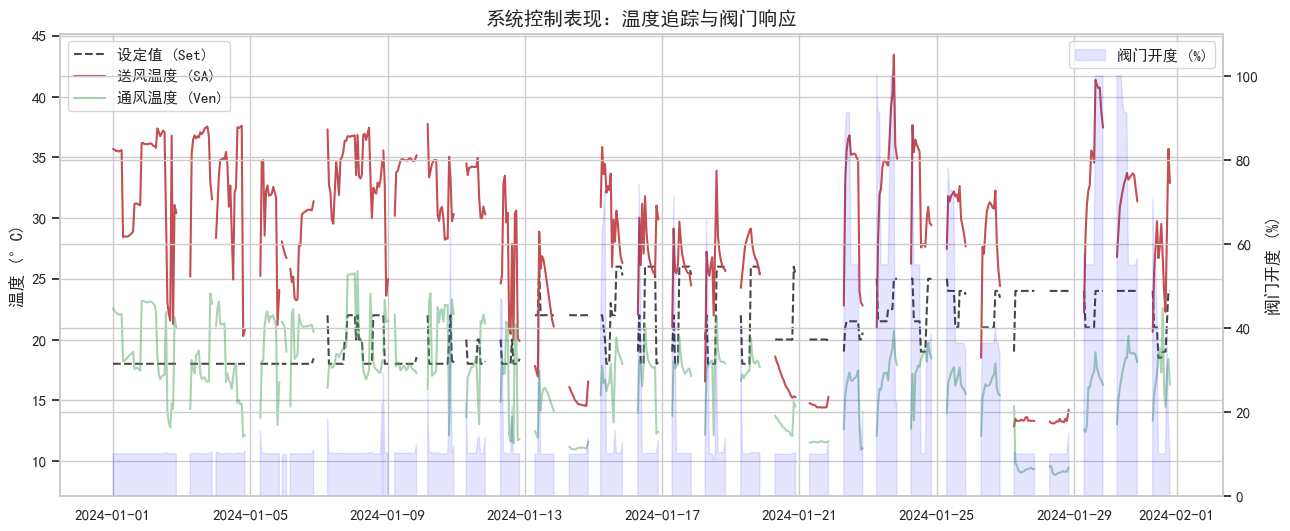

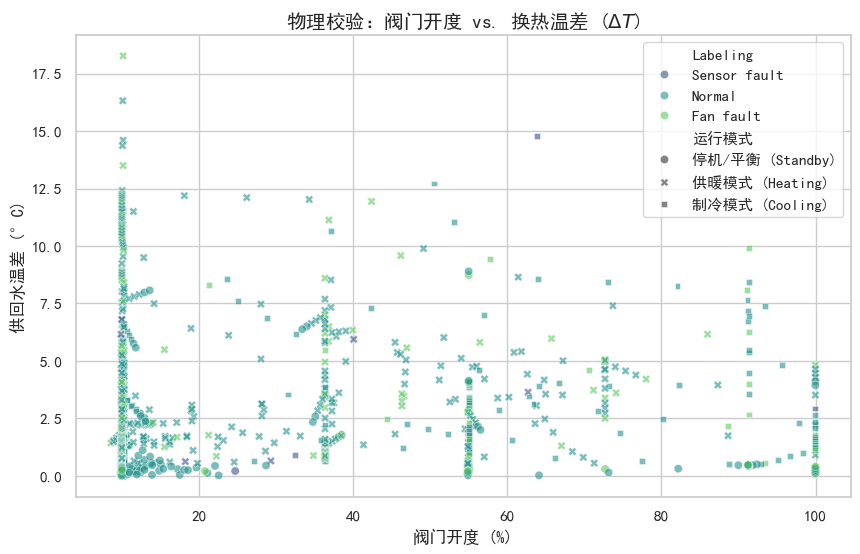

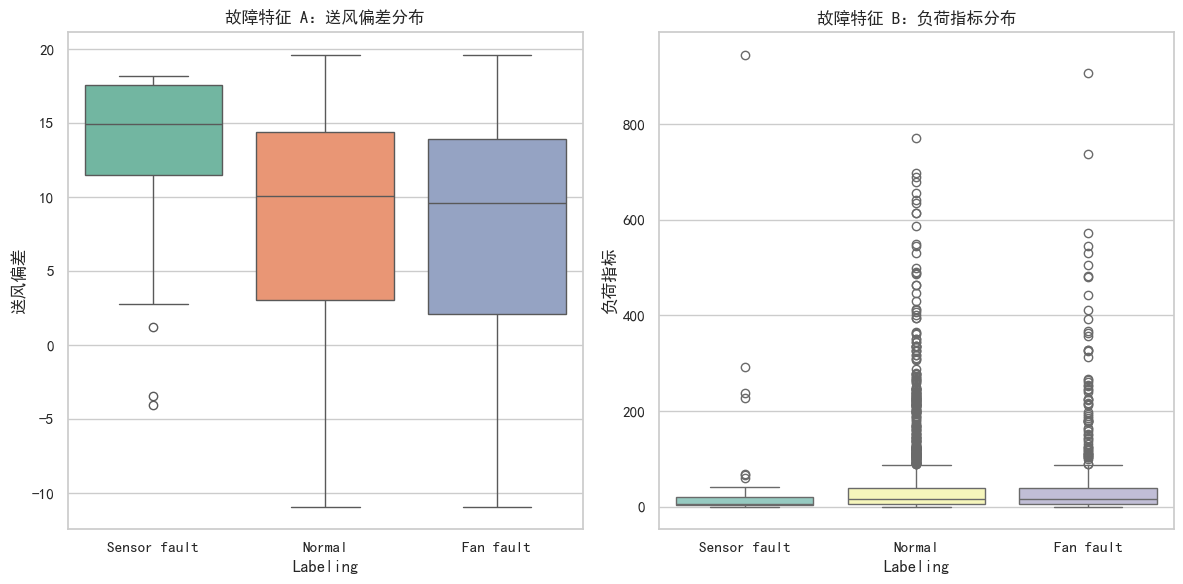

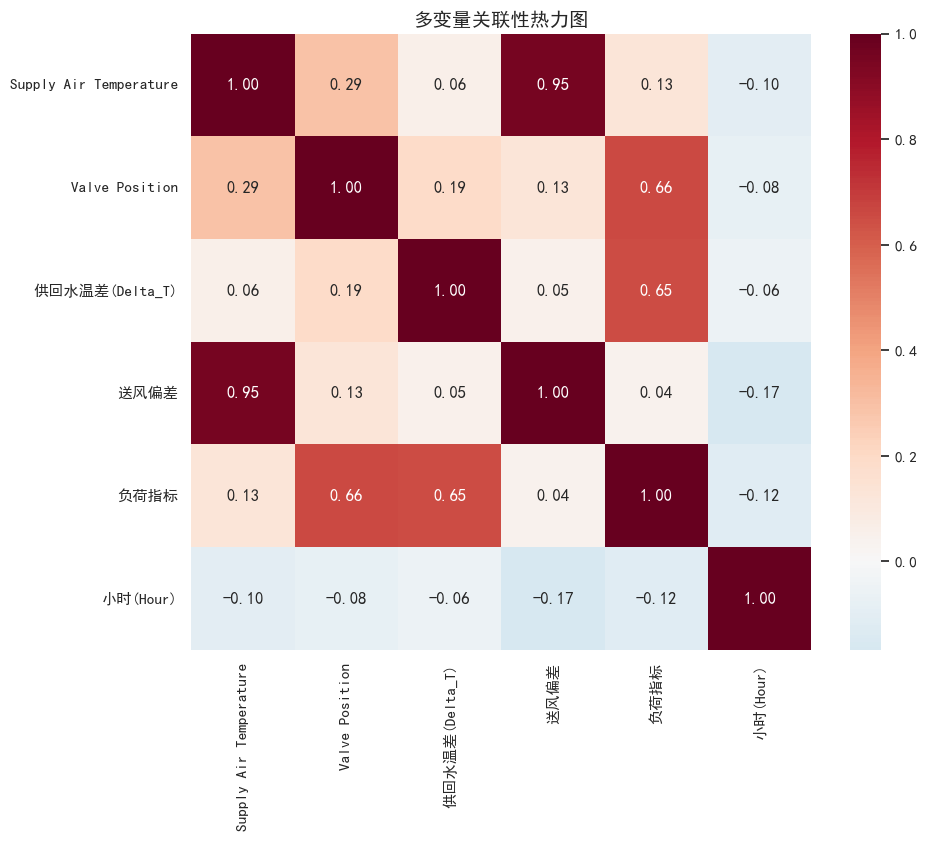

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 环境准备：创建输出文件夹
output_dir = '03_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 设置绘图风格
sns.set_theme(style="whitegrid", font="SimHei") # 如果环境中没有黑体，可改回 sans-serif
plt.rcParams['axes.unicode_minus'] = False 

# ---------------------------------------------------------
# 图 1：系统控制表现 (Time Series)
# ---------------------------------------------------------
plt.figure(figsize=(15, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# 绘制温度主轴
ax1.plot(df.index, df['Set Temperature'], 'k--', label='设定值 (Set)', alpha=0.8)
ax1.plot(df.index, df['Supply Air Temperature'], 'r-', label='送风温度 (SA)', linewidth=1.5)
ax1.plot(df.index, df['Ventilation Temperature'], 'g-', label='通风温度 (Ven)', alpha=0.5)

# 绘制阀门副轴
ax2.fill_between(df.index, 0, df['Valve Position'], color='blue', alpha=0.1, label='阀门开度 (%)')
ax2.set_ylim(0, 110)

ax1.set_title('系统控制表现：温度追踪与阀门响应', fontsize=14)
ax1.set_ylabel('温度 (°C)')
ax2.set_ylabel('阀门开度 (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.savefig(f'{output_dir}/01_system_performance.png', dpi=300)
print("💾 已保存：01_system_performance.png")

# ---------------------------------------------------------
# 图 2：换热物理逻辑 (Scatter Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Valve Position', y='供回水温差(Delta_T)', hue='Labeling', style='运行模式', palette='viridis', alpha=0.6)
plt.title('物理校验：阀门开度 vs. 换热温差 ($\Delta T$)', fontsize=14)
plt.xlabel('阀门开度 (%)')
plt.ylabel('供回水温差 (°C)')

plt.savefig(f'{output_dir}/02_heat_exchange_logic.png', dpi=300)
print("💾 已保存：02_heat_exchange_logic.png")

# ---------------------------------------------------------
# 图 3：故障指纹提取 (Box Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Labeling', y='送风偏差', palette='Set2')
plt.title('故障特征 A：送风偏差分布')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Labeling', y='负荷指标', palette='Set3')
plt.title('故障特征 B：负荷指标分布')

plt.tight_layout()
plt.savefig(f'{output_dir}/03_fault_fingerprints.png', dpi=300)
print("💾 已保存：03_fault_fingerprints.png")

# ---------------------------------------------------------
# 图 4：特征关联性扫描 (Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
corr_cols = ['Supply Air Temperature', 'Valve Position', '供回水温差(Delta_T)', '送风偏差', '负荷指标', '小时(Hour)']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('多变量关联性热力图', fontsize=14)

plt.savefig(f'{output_dir}/04_correlation_heatmap.png', dpi=300)
print("💾 已保存：04_correlation_heatmap.png")

plt.show()

In [32]:
# 建议导出最终清洗并包含特征的数据集，供后续机器学习模型使用
df.to_csv('03_output/final_cleaned_ahu_data.csv')
print("🎉 恭喜！全流程数据预处理已完成，最终数据已存入 03_output。")

🎉 恭喜！全流程数据预处理已完成，最终数据已存入 03_output。


In [ ]:
# 送风温度 (SA) 物理常识校验 — 对齐 .cursorrules
# 规则摘要：制冷 SA 常见 12–18℃；供暖 SA 常见 30–50℃；SA < 0 或 > 70 视为坏点。
# 制冷工况判定（数据无“模式”列时）：热水供水温度1 < 38℃（不以供暖盘管为主）且 设定温度 ≤ 24℃。

sa_col = "Supply Air Temperature"
hst_col = "Heating Supply Temperature 1"
set_col = "Set Temperature"

sa = pd.to_numeric(df[sa_col], errors="coerce")
hst = pd.to_numeric(df[hst_col], errors="coerce")
set_t = pd.to_numeric(df[set_col], errors="coerce")

cooling_mode = (hst < 38) & (set_t <= 24)

bad_sensor = (sa < 0) | (sa > 70)
cooling_bad = cooling_mode & ((sa > 30) | (sa < 5))

mask_any = bad_sensor | cooling_bad
df_sa_issues = df.loc[mask_any].copy()
df_sa_issues["_reason"] = ""
df_sa_issues.loc[bad_sensor[mask_any], "_reason"] += "全局坏点(SA<0或>70); "
df_sa_issues.loc[cooling_bad[mask_any], "_reason"] += "制冷工况下SA>30或SA<5; "
df_sa_issues["_reason"] = df_sa_issues["_reason"].str.rstrip("; ")

print(f"送风温度相关异常行数: {len(df_sa_issues)}")
print(f"  其中全局坏点 SA<0 或 >70: {bad_sensor.sum()}")
print(f"  其中制冷工况下 SA>30 或 SA<5: {cooling_bad.sum()}")
df_sa_issues